In [ ]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License

In [1]:
import sys
import pathlib
import os
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.parent.resolve()))
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.resolve()))

In [2]:
import qiskit
import matplotlib.pyplot as plt
%matplotlib inline

In [17]:
from _helpers.circuit_submitter import CircuitSubmitter
from rb import RandomizedBenchmarking

device_name = "noisy_sim"
submitter = CircuitSubmitter("clifford_randomized_benchmarking", device_name)

# Uncomment the following lines if you are using a noisy simulator and would like to change the noise model
# noise_model = None
# submitter.backend.device.set_noise_model(noise_model=noise_model)

# Clifford Randomized benchmarking
### 1 qubit Clifford RB

In [18]:
rb_exp_1q = RandomizedBenchmarking(n_qubits=1, n_cliffords=[0, 50, 100, 200, 400, 600], samples_per_depth=30)
all_circs = rb_exp_1q.generate_all_circuits()
all_counts = {}
shots = 10240
for depth, circs in all_circs.items():
    t_circs = qiskit.transpile(circs, basis_gates = ['cx', 'id', 'rz', 'sx'])
    submitter.submit_circuits(shots, qasm_strs=[c.qasm() for c in t_circs], skip_asking=True, skip_transpilation=True)
    all_counts[depth] = [submitter.convert_counts_to_qiskit(counts) for counts in submitter.retrieve_counts()]
rb_exp_1q.load_counts(all_counts, shots = shots)


Ready to run 30 circuits on noisy_sim with 10240 shots.
Cost: 30 * ($0 + 10240 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:35:21 All circuits are finished
Ready to run 30 circuits on noisy_sim with 10240 shots.
Cost: 30 * ($0 + 10240 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:35:26 All circuits are finished
Ready to run 30 circuits on noisy_sim with 10240 shots.
Cost: 30 * ($0 + 10240 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:35:31 All circuits are finished
Ready to run 30 circuits on noisy_sim with 10240 shots.
Cost: 30 * ($0 + 10240 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:35:38 All circuits are finished
Ready to run 30 circuits on noisy_sim with 10240 shots.
Cost: 30 * ($0 + 10240 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:35:48 All circuits are finished
Ready to run 30 circuits on noisy_sim with 10240 shots.
Cost: 30 * ($0 + 10240 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:36:00 All circuits

The Clifford randomized benchmarking average gate error is 0.001820551268484738


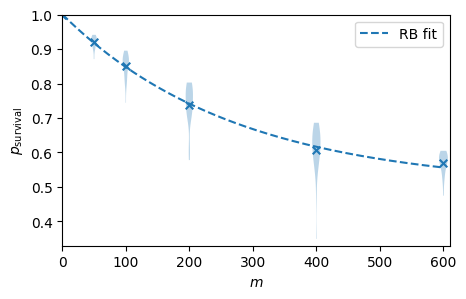

In [19]:
# a_0 * np.power(alpha, m) + b_0
alpha, a_0, b_0 = 0.99,1,0
initial_guess = (alpha, a_0, b_0) 
rb_exp_1q.get_fit(initial_guess = initial_guess)
average_gate_error = rb_exp_1q.get_average_gate_error()
fig = plt.figure(figsize=(5,3))
rb_exp_1q.plot_rb_results()
plt.legend()
plt.show()

### 2 qubit Clifford RB

In [8]:
rb_exp_2q = RandomizedBenchmarking(n_qubits=2, n_cliffords=[0,2, 4, 8, 16, 32, 64,])
all_circs = rb_exp_2q.generate_all_circuits()
all_counts = {}
shots = 1024
for depth, circs in all_circs.items():
    submitter.submit_circuits(shots, qasm_strs=[c.qasm() for c in circs], skip_asking=True)
    all_counts[depth] = [submitter.convert_counts_to_qiskit(counts) for counts in submitter.retrieve_counts()]
rb_exp_2q.load_counts(all_counts, shots = shots)


Ready to run 10 circuits on noisy_sim with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:29:23 All circuits are finished
Ready to run 10 circuits on noisy_sim with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:29:26 All circuits are finished
Ready to run 10 circuits on noisy_sim with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:29:28 All circuits are finished
Ready to run 10 circuits on noisy_sim with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:29:31 All circuits are finished
Ready to run 10 circuits on noisy_sim with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:29:33 All circuits are finished
Ready to run 10 circuits on noisy_sim with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:29:36 All circuits are finishe

The Clifford randomized benchmarking average gate error is 0.054476184475512


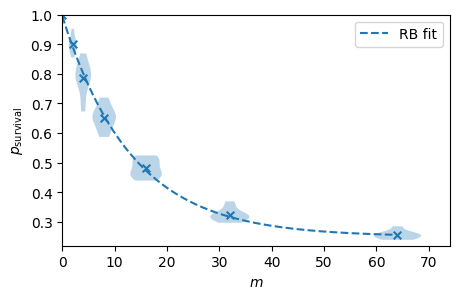

In [28]:
rb_exp_2q.get_fit(initial_guess=(0.999,1,0))
rb_exp_2q.get_average_gate_error()
fig = plt.figure(figsize=(5,3))
rb_exp_2q.plot_rb_results()
plt.legend()
plt.show()